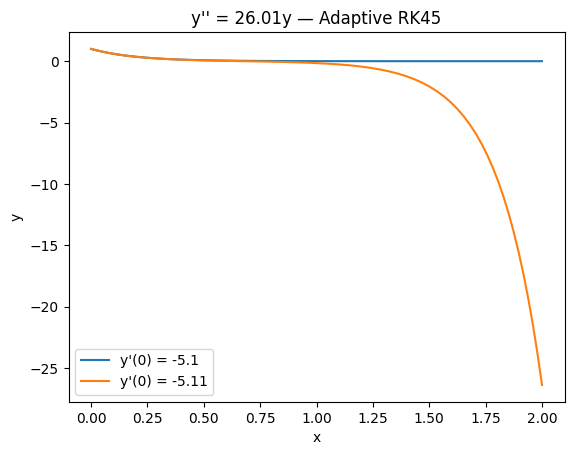

The difference in solutions is a real reflection of the vast difference in solutions due to small variations in the initial conditions


In [21]:
import math
import numpy as np
import matplotlib.pyplot as plt

## module run_kut5
def integrate(F, x, y, xStop, h, tol=1.0e-6):
    a1 = 0.2; a2 = 0.3; a3 = 0.8; a4 = 8/9; a5 = 1.0
    a6 = 1.0

    c0 = 35/384; c2 = 500/1113; c3 = 125/192
    c4 = -2187/6784; c5 = 11/84

    d0 = 5179/57600; d2 = 7571/16695; d3 = 393/640
    d4 = -92097/339200; d5 = 187/2100; d6 = 1/40

    b10 = 0.2
    b20 = 0.075; b21 = 0.225
    b30 = 44/45; b31 = -56/15; b32 = 32/9
    b40 = 19372/6561; b41 = -25360/2187; b42 = 64448/6561
    b43 = -212/729
    b50 = 9017/3168; b51 = -355/33; b52 = 46732/5247
    b53 = 49/176; b54 = -5103/18656
    b60 = 35/384; b62 = 500/1113; b63 = 125/192
    b64 = -2187/6784; b65 = 11/84

    X = []
    Y = []
    X.append(x)
    Y.append(y)
    stopper = 0
    k0 = h * F(x, y)

    for i in range(10000):
        k1 = h * F(x + a1*h, y + b10*k0)
        k2 = h * F(x + a2*h, y + b20*k0 + b21*k1)
        k3 = h * F(x + a3*h, y + b30*k0 + b31*k1 + b32*k2)
        k4 = h * F(x + a4*h, y + b40*k0 + b41*k1 + b42*k2 + b43*k3)
        k5 = h * F(x + a5*h, y + b50*k0 + b51*k1 + b52*k2 + b53*k3 + b54*k4)
        k6 = h * F(x + a6*h, y + b60*k0 + b62*k2 + b63*k3 + b64*k4 + b65*k5)

        dy = c0*k0 + c2*k2 + c3*k3 + c4*k4 + c5*k5
        E = (c0 - d0)*k0 + (c2 - d2)*k2 + (c3 - d3)*k3 \
            + (c4 - d4)*k4 + (c5 - d5)*k5 - d6*k6
        e = math.sqrt(np.sum(E**2) / len(y))
        hNext = 0.9 * h * (tol / e)**0.2

        if e <= tol:
            y = y + dy
            x = x + h
            X.append(x)
            Y.append(y)
            if stopper == 1:
                break
            if abs(hNext) > 10.0 * abs(h):
                hNext = 10.0 * h
            if (h > 0.0) == ((x + hNext) >= xStop):
                hNext = xStop - x
                stopper = 1
            k0 = k6 * hNext / h
        else:
            if abs(hNext) < 0.1 * abs(h):
                hNext = 0.1 * h
            k0 = k0 * hNext / h

        h = hNext

    return np.array(X), np.array(Y)


# y'' = 26.01y  =>  y[0] = y, y[1] = y'
# y'[0] = y[1]
# y'[1] = 26.01 * y[0]
def F(x, y):
    return np.array([y[1], 26.01 * y[0]])


x0 = 0.0
xStop = 2.0
h = 0.1

# Case 1: y(0)=1, y'(0)=-5.1
y0_case1 = np.array([1.0, -5.1])
X1, Y1 = integrate(F, x0, y0_case1, xStop, h)

# Case 2: y(0)=1, y'(0)=-5.11
y0_case2 = np.array([1.0, -5.11])
X2, Y2 = integrate(F, x0, y0_case2, xStop, h)

plt.plot(X1, Y1[:, 0], label="y'(0) = -5.1")
plt.plot(X2, Y2[:, 0], label="y'(0) = -5.11")
plt.xlabel("x")
plt.ylabel("y")
plt.title("y'' = 26.01y — Adaptive RK45")
plt.legend()
plt.show()

print("The difference in solutions is a real reflection of the vast difference in solutions due to small variations in the initial conditions")


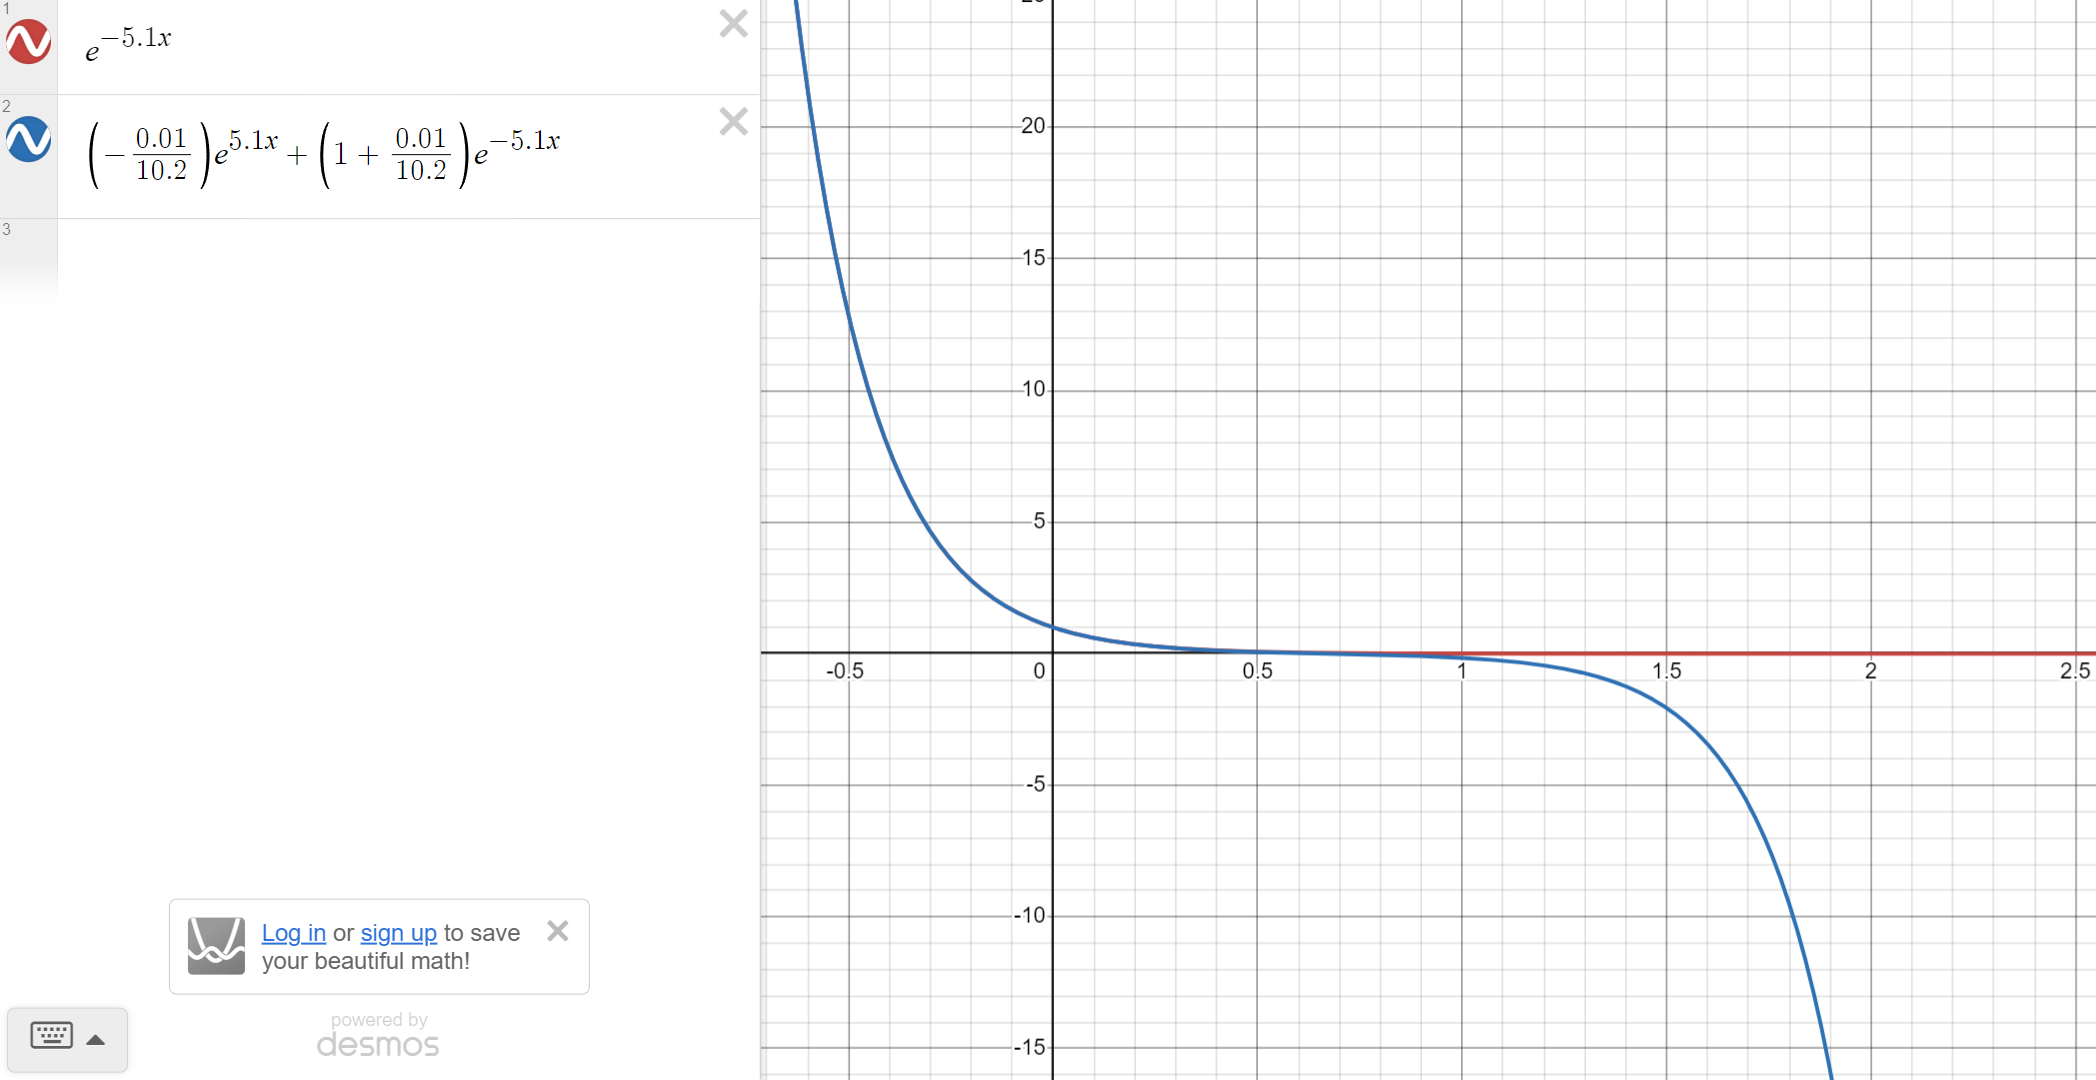

 x (m)   Analytical (°C)    FDM (°C)   Error (°C)
--------------------------------------------------
   0.0           40.0000     40.0000       0.0000
   2.0          179.0080    184.1280       5.1200
   4.0          261.0560    266.8160       5.7600
   6.0          276.5440    280.3840       3.8400
   8.0          246.5920    247.8720       1.2800
  10.0          200.0000    200.0000       0.0000


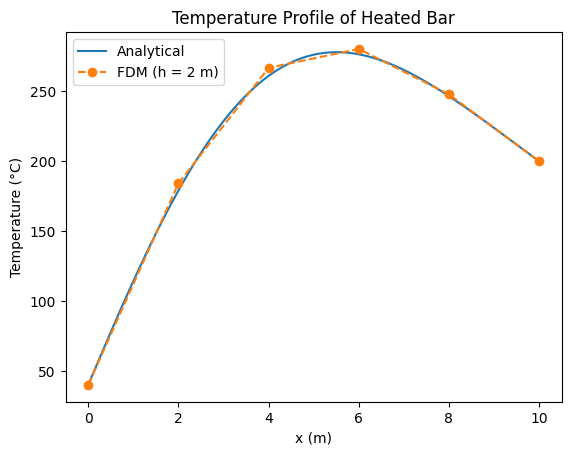

In [22]:
import numpy as np
import matplotlib.pyplot as plt

## module gaussElimin
def gaussElimin(a, b):
    n = len(b)
    # Elimination Phase
    for k in range(0, n-1):
        for i in range(k+1, n):
            if a[i, k] != 0.0:
                lam = a[i, k] / a[k, k]
                a[i, k+1:n] = a[i, k+1:n] - lam*a[k, k+1:n]
                b[i] = b[i] - lam*b[k]
    # Back substitution
    for k in range(n-1, -1, -1):
        b[k] = (b[k] - np.dot(a[k, k+1:n], b[k+1:n])) / a[k, k]
    return b

# --- Analytical Solution ---
def T_analytical(x):
    return -0.006*x**5 + 0.2*x**4 - 2*x**3 + 76*x + 40

def f(x):
    return 0.12*x**3 - 2.4*x**2 + 12*x

# --- Finite Difference Method ---
h = 2.0
x_nodes = np.arange(0, 10 + h, h)
n = len(x_nodes)

T0 = 40.0
TL = 200.0

n_int = n - 2

A = np.zeros((n_int, n_int))
b = np.zeros(n_int)

for i in range(n_int):
    xi = x_nodes[i + 1]
    rhs = -f(xi) * h**2

    if i == 0:
        A[i, i]   = -2.0
        A[i, i+1] =  1.0
        b[i] = rhs - T0
    elif i == n_int - 1:
        A[i, i-1] =  1.0
        A[i, i]   = -2.0
        b[i] = rhs - TL
    else:
        A[i, i-1] =  1.0
        A[i, i]   = -2.0
        A[i, i+1] =  1.0
        b[i] = rhs

T_interior = gaussElimin(A, b)
T_fdm = np.concatenate(([T0], T_interior, [TL]))

x_fine = np.linspace(0, 10, 500)
T_exact_fine = T_analytical(x_fine)
T_exact_nodes = T_analytical(x_nodes)

print(f"{'x (m)':>6}  {'Analytical (°C)':>16}  {'FDM (°C)':>10}  {'Error (°C)':>11}")
print("-" * 50)
for i in range(n):
    print(f"{x_nodes[i]:>6.1f}  {T_exact_nodes[i]:>16.4f}  {T_fdm[i]:>10.4f}  {T_fdm[i]-T_exact_nodes[i]:>11.4f}")

# --- Plot ---
plt.plot(x_fine, T_exact_fine, label='Analytical')
plt.plot(x_nodes, T_fdm, 'o--', label='FDM (h = 2 m)')
plt.xlabel('x (m)')
plt.ylabel('Temperature (°C)')
plt.title('Temperature Profile of Heated Bar')
plt.legend()
plt.show()

In [23]:
import numpy as np

## trapezoid (composite)
def trapezoid(f, a, b, n):
    h = (b - a) / n
    x = np.linspace(a, b, n + 1)
    fx = np.array([f(xi) for xi in x])
    I = (fx[0] + 2.0*np.sum(fx[1:-1]) + fx[-1]) * h / 2.0
    return I

## module simpson (composite 1/3 rule)
def simpson(f, a, b, n):
    h = (b - a) / n
    x = np.linspace(a, b, n + 1)
    fx = np.array([f(xi) for xi in x])
    coeffs = np.ones(n + 1)
    coeffs[1:-1:2] = 4.0   # odd indices  -> 4
    coeffs[2:-2:2] = 2.0   # even indices -> 2
    I = np.dot(coeffs, fx) * h / 3.0
    return I

#Function and solution
def f(x):
    return 5 + 0.3*x**2

def analytical(a, b):
    return (5*b + 0.1*b**3) - (5*a + 0.1*a**3)

a, b = 0.0, 11.0
n = 10

I_exact = analytical(a, b)
I_trap  = trapezoid(f, a, b, n)
I_simp  = simpson(f, a, b, n)

print(f"Analytical:          {I_exact:.6f}")
print(f"Trapezoidal (n=10):  {I_trap:.6f}  |  Error: {I_trap - I_exact:.6f}")
print(f"Simpson 1/3 (n=10):  {I_simp:.6f}  |  Error: {I_simp - I_exact:.6f}")

Analytical:          188.100000
Trapezoidal (n=10):  188.765500  |  Error: 0.665500
Simpson 1/3 (n=10):  188.100000  |  Error: 0.000000


    x    Analytical       Euler        Heun     Ralston         RK4
-----------------------------------------------------------------
  0.0      1.000000    1.000000    1.000000    1.000000    1.000000
  0.1      1.113025    1.100000    1.112929    1.112788    1.113025
  0.2      1.254400    1.225857    1.254159    1.253850    1.254400
  0.3      1.428025    1.380863    1.427579    1.427072    1.428024
  0.4      1.638400    1.568879    1.637671    1.636940    1.638399
  0.5      1.890625    1.794338    1.889520    1.888536    1.890624
  0.6      2.190400    2.062244    2.188813    2.187547    2.190398
  0.7      2.544025    2.378175    2.541832    2.540255    2.544023
  0.8      2.958400    2.748287    2.955463    2.953546    2.958397
  0.9      3.441025    3.179314    3.437192    3.434905    3.441021
  1.0      4.000000    3.678572    3.995105    3.992417    3.999995

Error at x = 1.0 (numerical - analytical):
  Euler:   -0.321428
  Heun:    -0.004895
  Ralston: -0.007583
  RK4:     

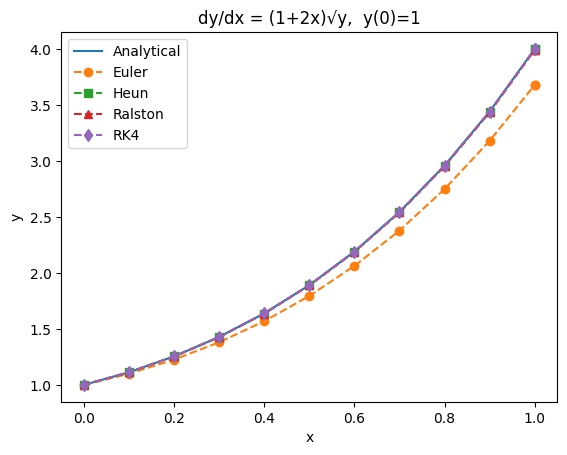

In [24]:
import numpy as np
import matplotlib.pyplot as plt

def f(x, y):
    return (1 + 2*x) * np.sqrt(y)

def analytical(x):
    return (x**2/2 + x/2 + 1)**2

def euler(f, x, y, xStop, h):
    X = [x]; Y = [y]
    while x < xStop:
        h = min(h, xStop - x)
        y = y + h * f(x, y)
        x = x + h
        X.append(x); Y.append(y)
    return np.array(X), np.array(Y)

def heun(f, x0, y0, xStop, h):
    X = [x0]; Y = [y0]
    x, y = x0, y0
    while x < xStop:
        h = min(h, xStop - x)
        k1 = f(x, y)
        k2 = f(x + h, y + h*k1)
        y = y + (h/2) * (k1 + k2)
        x = x + h
        X.append(x); Y.append(y)
    return np.array(X), np.array(Y)

def ralston(f, x0, y0, xStop, h):
    X = [x0]; Y = [y0]
    x, y = x0, y0
    while x < xStop:
        h = min(h, xStop - x)
        k1 = f(x, y)
        k2 = f(x + 2*h/3, y + 2*h/3 * k1)
        y = y + h * (k1/4 + 3*k2/4)
        x = x + h
        X.append(x); Y.append(y)
    return np.array(X), np.array(Y)

def rk4(f, x0, y0, xStop, h):
    X = [x0]; Y = [y0]
    x, y = x0, y0
    while x < xStop:
        h = min(h, xStop - x)
        k1 = f(x, y)
        k2 = f(x + h/2, y + h/2 * k1)
        k3 = f(x + h/2, y + h/2 * k2)
        k4 = f(x + h,   y + h   * k3)
        y = y + (h/6) * (k1 + 2*k2 + 2*k3 + k4)
        x = x + h
        X.append(x); Y.append(y)
    return np.array(X), np.array(Y)

x0, y0  = 0.0, 1.0
xStop   = 1.0
h       = 0.1

# Analytical at each step
x_exact = np.arange(x0, xStop + h, h)
y_exact = analytical(x_exact)

# Numerical solutions
X_eu, Y_eu = euler(f, x0, y0, xStop, h)
X_he, Y_he = heun(f, x0, y0, xStop, h)
X_ra, Y_ra = ralston(f, x0, y0, xStop, h)
X_rk, Y_rk = rk4(f, x0, y0, xStop, h)

#RESULTS
print(f"{'x':>5}  {'Analytical':>12}  {'Euler':>10}  {'Heun':>10}  {'Ralston':>10}  {'RK4':>10}")
print("-" * 65)
for i in range(len(x_exact)):
    print(f"{x_exact[i]:>5.1f}  {y_exact[i]:>12.6f}  {Y_eu[i]:>10.6f}  "
          f"{Y_he[i]:>10.6f}  {Y_ra[i]:>10.6f}  {Y_rk[i]:>10.6f}")

#ERRORS
print("\nError at x = 1.0 (numerical - analytical):")
print(f"  Euler:   {Y_eu[-1] - y_exact[-1]:>+.6f}")
print(f"  Heun:    {Y_he[-1] - y_exact[-1]:>+.6f}")
print(f"  Ralston: {Y_ra[-1] - y_exact[-1]:>+.6f}")
print(f"  RK4:     {Y_rk[-1] - y_exact[-1]:>+.6f}")

# PLOT
plt.plot(x_exact, y_exact,  label='Analytical')
plt.plot(X_eu, Y_eu, 'o--', label='Euler')
plt.plot(X_he, Y_he, 's--', label="Heun")
plt.plot(X_ra, Y_ra, '^--', label="Ralston")
plt.plot(X_rk, Y_rk, 'd--', label='RK4')
plt.xlabel('x')
plt.ylabel('y')
plt.title("dy/dx = (1+2x)√y,  y(0)=1")
plt.legend()
plt.show()